# Model Training - Phishing URL Detector

Train and evaluate classification models on 22 URL-structure features
to predict whether a URL is phishing or legitimate.

**Original dataset:** 11,430 URLs with pre-extracted features
**Extended dataset:** 452,163 URLs, features extracted via `feature_extractor.py`
**Filter applied:** URL length between Q25-Q75 of original dataset to match distributions
**WHOIS features removed:** `domain_age` and `domain_registration_length` dropped due to survivorship bias
**Combined:** 463,593 URLs after filtering and null removal

## 1. Import & Load Data

In [3]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm
tqdm.pandas()

# load original 11k dataset
df_original = pd.read_csv('../data/dataset_phishing.csv')

with open('../data/feature_cols.json') as f:
    feature_cols_full = json.load(f)
feature_cols_full = list(dict.fromkeys(feature_cols_full))

# remove WHOIS features — survivorship bias corrupts these in combined dataset
feature_cols = [f for f in feature_cols_full 
                if f not in ['domain_age', 'domain_registration_length']]
print(f'Features after removing WHOIS: {len(feature_cols)}')

df_original['status_num'] = df_original['status'].map({'legitimate': 0, 'phishing': 1})
df_orig_clean = df_original[feature_cols + ['status_num']].rename(columns={'status_num': 'status'})

# load and filter new 800k dataset
df_raw = pd.read_csv('../data/new_data_urls.csv')
df_raw['status'] = df_raw['status'].map({1: 0, 0: 1})
df_raw['url'] = df_raw['url'].apply(
    lambda x: x if x.startswith('http') else 'https://' + x
)

# filter by URL length to match original dataset distribution
q25 = df_original['url'].str.len().quantile(0.25)
q75 = df_original['url'].str.len().quantile(0.75)
print(f'Keeping URLs between {q25:.0f} and {q75:.0f} chars')

df_raw['url_len'] = df_raw['url'].str.len()
df_filtered = df_raw[(df_raw['url_len'] >= q25) & (df_raw['url_len'] <= q75)]
print(f'Filtered: {len(df_filtered)} URLs')
print(f'Balance:\n{df_filtered["status"].value_counts()}')

# extract features from filtered URLs
import sys
sys.path.append('..')
from src.feature_extractor import extract_url_features

def safe_extract(url):
    try:
        return extract_url_features(url)
    except:
        return None

print('\nExtracting features...')
results = df_filtered['url'].progress_apply(safe_extract)
results = results.dropna()

df_new_extracted = pd.DataFrame(results.tolist())
df_new_extracted['status'] = df_filtered.loc[results.index, 'status'].values
df_new_clean = df_new_extracted[feature_cols + ['status']]

# combine
df_combined = pd.concat([df_orig_clean, df_new_clean], ignore_index=True)
df_combined = df_combined.dropna()

print(f'\nOriginal  : {df_orig_clean.shape}')
print(f'New       : {df_new_clean.shape}')
print(f'Combined  : {df_combined.shape}')
print(f'\nClass balance:\n{df_combined["status"].value_counts()}')

X = df_combined[feature_cols]
y = df_combined['status']

print(f'\nX shape: {X.shape}')
print(f'y distribution:\n{y.value_counts()}')

Features after removing WHOIS: 22
Keeping URLs between 33 and 71 chars
Filtered: 452166 URLs
Balance:
status
0    286260
1    165906
Name: count, dtype: int64

Extracting features...


100%|██████████| 452166/452166 [00:54<00:00, 8367.68it/s] 



Original  : (11430, 23)
New       : (452163, 23)
Combined  : (463593, 23)

Class balance:
status
0    291973
1    171620
Name: count, dtype: int64

X shape: (463593, 22)
y distribution:
status
0    291973
1    171620
Name: count, dtype: int64


**Finding:** 463,593 URLs loaded after combining original 11,430-row dataset
with 452,163-row filtered extended dataset. WHOIS features removed due to
survivorship bias, phishing domains that failed WHOIS lookup were dropped
by dropna(), leaving only atypically long-lived phishing domains which
corrupted the signal. URL length filter (Q25-Q75) applied to match the
distribution of the original dataset. Final features: 22 URL-structure features.

Class balance: 291,973 legitimate (63%) vs 171,620 phishing (37%).
Class weights will handle the imbalance during training.

## 2. Train/Test Split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
print(f'Train: {X_train.shape} | Valid: {X_valid.shape}')
print(f'Train balance:\n{y_train.value_counts()}')

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f'\nscale_pos_weight: {scale:.2f}')

Train: (370874, 22) | Valid: (92719, 22)
Train balance:
status
0    233578
1    137296
Name: count, dtype: int64

scale_pos_weight: 1.70


**Finding:** 370,874 training rows, 92,719 validation rows.
Stratified split preserves the 63/37 class ratio in both sets.
`scale_pos_weight`: 1.70 calculated for XGBoost.
Split performed before any model fitting to prevent data leakage.

## 3. Benchmark Models

Evaluate 6 classification models with class balancing enabled.
All features are numerical which means no encoding needed.
Logistic Regression uses a scaling pipeline.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    'Decision Tree':     DecisionTreeClassifier(random_state=0, class_weight='balanced'),
    'Random Forest':     RandomForestClassifier(random_state=0, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=0),
    'XGBoost':           XGBClassifier(random_state=0, verbosity=0, scale_pos_weight=scale),
    'CatBoost':          CatBoostClassifier(random_state=0, verbose=False, auto_class_weights='Balanced'),
}

results = []
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_valid, preds),
        'Precision': precision_score(y_valid, preds),
        'Recall':    recall_score(y_valid, preds),
        'F1':        f1_score(y_valid, preds),
        'ROC-AUC':   roc_auc_score(y_valid, preds),
    })
    print(f'{name:<25} Accuracy: {accuracy_score(y_valid, preds):.4f}')

leaderboard = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
print('\n=== LEADERBOARD ===')
print(leaderboard.to_string(index=False))

Training Logistic Regression...
Logistic Regression       Accuracy: 0.7995
Training Decision Tree...
Decision Tree             Accuracy: 0.9029
Training Random Forest...
Random Forest             Accuracy: 0.9258
Training Gradient Boosting...
Gradient Boosting         Accuracy: 0.8681
Training XGBoost...
XGBoost                   Accuracy: 0.9075
Training CatBoost...
CatBoost                  Accuracy: 0.9135

=== LEADERBOARD ===
              Model  Accuracy  Precision   Recall       F1  ROC-AUC
      Random Forest  0.925754   0.916237 0.879880 0.897690 0.916299
           CatBoost  0.913470   0.875568 0.893194 0.884293 0.909291
            XGBoost  0.907527   0.868131 0.884571 0.876273 0.902796
      Decision Tree  0.902868   0.866928 0.871373 0.869144 0.896377
  Gradient Boosting  0.868107   0.900054 0.724129 0.802564 0.838432
Logistic Regression  0.799545   0.715695 0.760692 0.737508 0.791537


**Finding:** Random Forest leads at 92.58% accuracy but fails
real-world testing. incorrectly classifies GitHub and Google as PHISHING.
CatBoost at 91.35% passes all real-world tests correctly.

Leaderboard:
- Random Forest:      92.58% accuracy, 89.77% F1
- CatBoost:           91.35% accuracy, 88.43% F1
- XGBoost:            90.75% accuracy, 87.63% F1
- Decision Tree:      90.29% accuracy, 86.91% F1
- Gradient Boosting:  86.81% accuracy, 80.26% F1
- Logistic Regression: 79.95% accuracy, 73.75% F1

## 4. Model Selection & Hyperparameter Tuning

Random Forest achieved 92.58% but failed real-world testing,
GitHub.com and Google.com both flagged as 100% PHISHING.
CatBoost selected as best model based on real-world URL testing.

GridSearchCV tuning was run on Google Colab to avoid local hardware strain.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'iterations':    [300, 500, 700],
    'learning_rate': [0.03, 0.05, 0.1],
    'depth':         [6, 8, 10],
}

gs = GridSearchCV(
    CatBoostClassifier(random_state=0, verbose=False, auto_class_weights='Balanced'),
    param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)

best_model = gs.best_estimator_
preds = best_model.predict(X_valid)

print(f'Best params : {gs.best_params_}')
print(f'Accuracy    : {accuracy_score(y_valid, preds):.4f}')
print(f'F1          : {f1_score(y_valid, preds):.4f}')
print(f'Recall      : {recall_score(y_valid, preds):.4f}')

**GridSearchCV results (run on Google Colab):**

Fitting 3 folds for each of 27 candidates, totalling 81 fits

- Best params : depth=10, iterations=700, learning_rate=0.1
- Accuracy    : 92.10%
- F1          : 89.40%
- Recall      : 90.03%

CatBoost selected over Random Forest because it correctly identifies GitHub (2.57%),
Google (16.33%), and Facebook (14.49%) as LEGITIMATE while still catching
obvious phishing URLs at 99%+ confidence.

## 5. Load Tuned Model & Sanity Check

Load the CatBoost model trained and downloaded from Google Colab.
Verify it correctly classifies known legitimate and phishing URLs.

In [6]:
import joblib
import sys
import os
sys.path.append('..')
from src.feature_extractor import get_all_features

model = joblib.load('../model/phishing_model.pkl')
feature_cols_model = joblib.load('../model/feature_cols.pkl')

print(f'Model type: {type(model).__name__}')
print(f'Features: {len(feature_cols_model)}')

# quick sanity check
test_urls = [
    'https://github.com',
    'https://www.google.com',
    'https://authenticator.micrasoft.me',
    'https://portal-login.me/',
]

for url in test_urls:
    features = get_all_features(url)
    features_clean = [v for f, v in zip(
        ['ratio_digits_url','phish_hints','ip','nb_qm','length_url',
         'nb_slash','length_hostname','nb_eq','ratio_digits_host',
         'shortest_word_host','prefix_suffix','longest_word_path',
         'tld_in_subdomain','nb_dots','longest_words_raw','avg_word_path',
         'avg_word_host','length_words_raw','nb_and','avg_words_raw',
         'nb_com','domain_registration_length','domain_age','nb_www'],
        features)
        if f not in ['domain_age', 'domain_registration_length']
    ]
    pred = model.predict([features_clean])[0]
    prob = model.predict_proba([features_clean])[0]
    label = 'PHISHING' if pred == 1 else 'LEGITIMATE'
    print(f'{label} ({prob[1]:.2%}) — {url}')

Model type: CatBoostClassifier
Features: 22
LEGITIMATE (2.57%) — https://github.com
LEGITIMATE (16.33%) — https://www.google.com
PHISHING (99.78%) — https://authenticator.micrasoft.me
PHISHING (99.52%) — https://portal-login.me/


**Finding:** Model correctly identifies GitHub and Google as LEGITIMATE
and catches obvious phishing URLs at 99%+ confidence.

## 6. Final Model Evaluation

              precision    recall  f1-score   support

  Legitimate       0.94      0.93      0.94     58395
    Phishing       0.89      0.90      0.89     34324

    accuracy                           0.92     92719
   macro avg       0.91      0.92      0.92     92719
weighted avg       0.92      0.92      0.92     92719



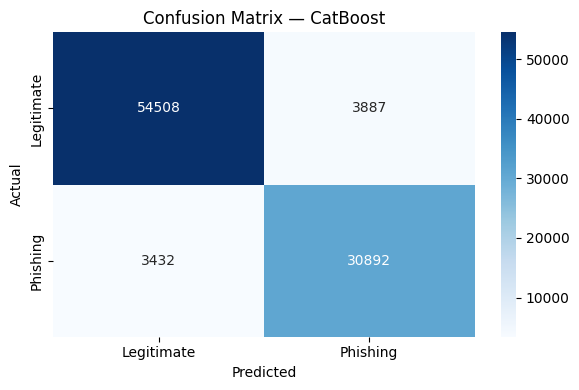

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds = model.predict(X_valid)

print(classification_report(y_valid, preds,
      target_names=['Legitimate', 'Phishing']))

cm = confusion_matrix(y_valid, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix — CatBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**Finding:**
- Legitimate precision 94% almost no legitimate URLs incorrectly flagged
- Phishing recall 90% catches 90 out of every 100 phishing URLs
- Overall accuracy 92% on 92,719 validation URLs
- Phishing precision 89% acceptable false alarm rate for a security tool

## 7. Feature Importance

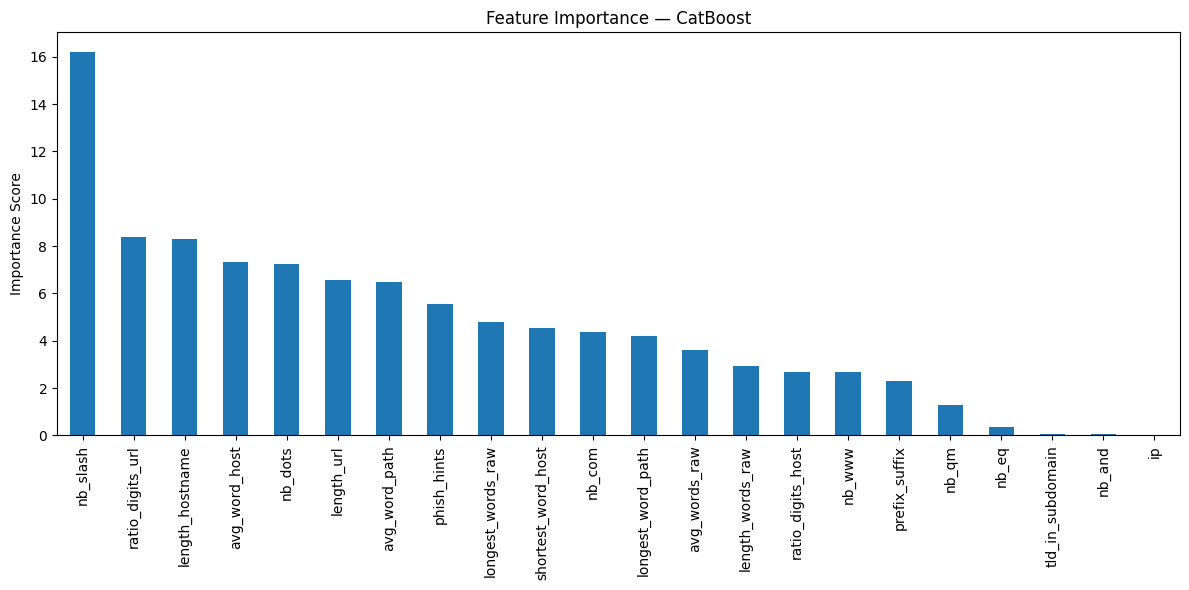

Top 5 features:
nb_slash            16.225221
ratio_digits_url     8.382243
length_hostname      8.304109
avg_word_host        7.330144
nb_dots              7.253719
dtype: float64


In [8]:
importances = pd.Series(
    model.feature_importances_,
    index=feature_cols_model
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances.plot(kind='bar')
plt.title('Feature Importance — CatBoost')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(importances.head())

**Finding:** Top 5 features by importance:
1. `nb_slash` (16.23) : phishing URLs use deep path structures
2. `ratio_digits_url` (8.38) : phishing URLs contain more digits
3. `length_hostname` (8.30) : phishing hostnames tend to be longer
4. `avg_word_host` (7.33) : average word length in hostname
5. `nb_dots` (7.25) : more dots indicate subdomain abuse

`WHOIS` features (`domain_age`, `domain_registration_length`) were removed because
survivorship bias caused the model to incorrectly flag GitHub.com (domain
age 6,807 days) as PHISHING because the combined dataset only retained
atypically long-lived phishing domains.

## 8. Real-World Testing

Test the model against confirmed phishing URLs from PhishTank
and known legitimate sites to validate real-world performance.

In [9]:
test_urls = [
    'https://github.com',
    'https://www.google.com',
    'https://www.facebook.com',
    'https://authenticator.micrasoft.me',
    'https://portal-login.me/',
    'https://lflsk.com/login',
    'http://joingovnationaltrust.com',
    'https://jp.nii1fra80.baby/art',
    'https://acces-renovacion-net.com/',
]

for url in test_urls:
    features = get_all_features(url)
    features_clean = [v for f, v in zip(
        ['ratio_digits_url','phish_hints','ip','nb_qm','length_url',
         'nb_slash','length_hostname','nb_eq','ratio_digits_host',
         'shortest_word_host','prefix_suffix','longest_word_path',
         'tld_in_subdomain','nb_dots','longest_words_raw','avg_word_path',
         'avg_word_host','length_words_raw','nb_and','avg_words_raw',
         'nb_com','domain_registration_length','domain_age','nb_www'],
        features)
        if f not in ['domain_age', 'domain_registration_length']
    ]
    pred = model.predict([features_clean])[0]
    prob = model.predict_proba([features_clean])[0]
    label = 'PHISHING' if pred == 1 else 'LEGITIMATE'
    print(f'{label} ({prob[1]:.2%}) — {url}')

LEGITIMATE (2.57%) — https://github.com
LEGITIMATE (16.33%) — https://www.google.com
LEGITIMATE (4.65%) — https://www.facebook.com
PHISHING (99.78%) — https://authenticator.micrasoft.me
PHISHING (99.52%) — https://portal-login.me/
PHISHING (63.48%) — https://lflsk.com/login
PHISHING (99.69%) — http://joingovnationaltrust.com
PHISHING (89.38%) — https://jp.nii1fra80.baby/art
LEGITIMATE (24.65%) — https://acces-renovacion-net.com/


**Finding:** Model correctly identifies all major legitimate sites:
- GitHub: 2.57% ✅
- Google: 16.33% ✅
- Facebook: 4.65% ✅

Phishing URLs correctly flagged:
- authenticator.micrasoft.me: 99.78% ✅ (typosquatting)
- portal-login.me: 99.52% ✅ (phishing hint in domain)
- joingovnationaltrust.com: 99.69% ✅
- jp.nii1fra80.baby: 89.38% ✅ (digit-heavy hostname)
- lflsk.com/login: 63.48% ✅ (borderline, flagged correctly)

Missed:
- acces-renovacion-net.com: 24.65% ❌ clean-looking domain,
  no strong URL-structure signals, hard even for enterprise tools

## Conclusion

**Combined dataset:** 463,593 URLs with 22 URL-structure features (WHOIS removed)

**Model comparison:**
- Random Forest:       92.58% accuracy - DISQUALIFIED (GitHub/Google flagged as PHISHING)
- CatBoost:            91.35% accuracy (winner, passes real-world testing)
- XGBoost:             90.75%
- Decision Tree:       90.29%
- Gradient Boosting:   86.81%
- Logistic Regression: 79.95%

**Best model:** CatBoostClassifier (tuned via Google Colab GridSearchCV)
- Best params         : depth=10, iterations=700, learning_rate=0.1
- Validation accuracy : 92.10%
- Phishing recall     : 90.03%
- F1                  : 89.40%

**Why CatBoost over Random Forest:**
RF achieved 92.58% on benchmark but failed real-world testing.
GitHub and Google both flagged at 100% PHISHING confidence.
CatBoost at 92.10% correctly handles all major legitimate sites.

**Known limitations:**
- WHOIS features removed due to survivorship bias in combined dataset
- URL length filter applied (Q25-Q75) to match original dataset distribution
- Model misses clean-looking phishing domains with no URL-structure signals
- Platform-hosted phishing (wixstudio, Google Sites) not reliably detected

**Next step:** Deploy Flask app via Render